# Entrega H2 — Modelo avanzado: CPGRec / CPGRec+
## IIC3633 Sistemas Recomendadores · Benjamín Suazo y Pablo Lagos

**CPGRec** (WWW'24) y su extensión **CPGRec+** son un framework GNN sobre LightGCN que
busca **equilibrar accuracy y diversidad** inyectando semántica de **categorías**
(género/desarrollador/editor) y de **popularidad** en la construcción de los grafos.
Módulos: **SGC** (grafos juego-juego con conexiones estrictas → accuracy), **CNA** (grafo
laxo G^Co → diversidad), **PENR** (reweighting por popularidad → cola larga), **NSR**
(fusión + BPR con reweighting de negativos). CPGRec+ añade **PER** (pesos de arista con
signo, sin LLM) y **PRG** (rama de contenido vía LLM, que aquí **aproximamos con nuestros
embeddings SBERT**).

Este notebook es **autocontenido** y reproduce el MISMO catálogo activo (k-core) y split
*leave-one-out* temporal de H1/SBERT, construye los grafos, **adapta y entrena el código
oficial** (https://github.com/HsipingLi/CPGRec-Plus) y evalúa con el **mismo harness** que
SBERT/ALS (P/R/NDCG @5/10/20 + Coverage/ILD/Novelty), dejando a CPGRec en la misma tabla.

### Alcance (toggles en la celda de config)
- `USE_PER=0, USE_CONTENT_EMB=0` → **CPGRec base** (SGC+CNA+PENR+NSR) — objetivo MUST.
- `USE_PER=1`            → **+PER** (reweighting con signo, dwelling time+rating) — SHOULD.
- `USE_CONTENT_EMB=1`            → **+PRG-SBERT** (rama de contenido con nuestros SBERT) — NICE.

### Cómo correrlo
1. Entorno → **GPU** (T4), idealmente *High-RAM*.
2. Ejecutar todo. Tiempo: leer `recommendations.csv` (~1.4 GB) + encode SBERT + entrenar.
3. **Dependencias DGL:** el repo se escribió para dgl 0.9/torch 1.12. La celda de install
   intenta `dgl` compatible con el torch de Colab; si la API de DGL difiere, puede requerir
   ajustar la versión (ver nota en esa celda).

## 0. Instalación e importaciones

In [1]:
# transformers/sentence-transformers PINEADOS a versiones compatibles con torch 2.4
# (DGL exige torch 2.4; el transformers reciente importa torch.distributed.tensor.device_mesh,
#  que NO existe en torch 2.4 -> rompe el import de SBERT). NO subir torch (rompe DGL).
!pip install -q kagglehub "transformers==4.44.2" "sentence-transformers==3.0.1" implicit

import importlib, importlib.util, torch

def _dgl_ok():
    importlib.invalidate_caches()
    return importlib.util.find_spec("dgl") is not None

torch_ok = torch.__version__.startswith("2.4")

if not torch_ok:
    print("Fijando torch 2.4 (compatible con el graphbolt de DGL)...")
    !pip install -q torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu118

if not _dgl_ok():
    !pip uninstall -y dgl 2>/dev/null
    !pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.4/cu118/repo.html
    !pip install -q torchdata==0.7.1 --no-deps

assert _dgl_ok(), "DGL no se instaló: revisá la salida de pip de arriba."

# transformers CARGADO en memoria debe ser 4.44 (si Colab pre-importo uno nuevo, pip lo bajo en
# disco pero el modulo viejo sigue en memoria -> hay que REINICIAR para que SBERT no rompa con
# torch 2.4: el transformers reciente importa torch.distributed.tensor.device_mesh, inexistente en 2.4).
import transformers
tf_ok = transformers.__version__.startswith("4.44")

if not torch_ok or not tf_ok:
    print(f"\n*** Reiniciando runtime para aplicar torch 2.4 / transformers 4.44 "
          f"(torch={torch.__version__}, transformers={transformers.__version__}). "
          f"Al reiniciar: Ejecutar todo de nuevo. ***")
    import IPython; IPython.Application.instance().kernel.do_shutdown(True)
else:
    import dgl; print("dgl", dgl.__version__, "| torch", torch.__version__,
                      "| transformers", transformers.__version__, "OK")

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
dgl 2.4.0+cu118 | torch 2.4.0+cu118 | transformers 4.44.2 OK


> **Nota:** la celda de arriba **reinicia el runtime** (para fijar torch 2.4 + DGL +
> transformers 4.44; un transformers mas nuevo rompe SBERT con torch 2.4). Es esperado: cuando reinicie, simplemente vuelve a *Ejecutar todo*. La segunda vez la
> celda ve que torch ya es 2.4 e importa DGL sin reinstalar nada. Si tras el reinicio el
> `import dgl` aún fallara, probar `cu118` en lugar de `cu121` en las dos líneas de install.

In [57]:
import os, json, shutil, zipfile, time, warnings, csv, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import kagglehub
warnings.filterwarnings('ignore')

# ── Config de datos/split (con TOGGLE de filtrado: ver FILTER_MODE) ──
SLUG             = "antonkozyriev/game-recommendations-on-steam"
FRONKON_SLUG     = "fronkongames/steam-games-dataset"
RANDOM_STATE     = 42
# ── Filtrado del catálogo (TOGGLE) ──
# "clasico"  = k-core >=5 resenas/usuario, >=20/juego  (el de H1/SBERT; catalogo grande y disperso)
# "agresivo" = k-core >=20/usuario, >=50/juego          (densifica hacia el regimen del paper; estilo G06/G09)
# El k-core es ITERATIVO en ambos casos (mas riguroso que filtrar una sola vez por separado).
FILTER_MODE = "clasico"                       # "clasico" | "agresivo"  (tunear el preset agresivo si se quiere mas denso)
_FILTER_PRESETS = {"clasico": (5, 20), "agresivo": (20, 50)}
MIN_USER_REVIEWS, MIN_GAME_REVIEWS = _FILTER_PRESETS[FILTER_MODE]
SAMPLE_FRAC      = 0.10  # universo de EVALUACION (de aqui salen los <=MAX_EVAL_USERS)
# ── Fraccion de usuarios para ENTRENAR, DESACOPLADA de la evaluacion (palanca #1) ──
# CPGRec es un GNN que propaga sobre el bipartito: mas usuarios -> grafo mas denso -> mas
# senal colaborativa. La EVALUACION se mantiene sobre el mismo set (SAMPLE_FRAC) para
# comparabilidad. Los usuarios de evaluacion SIEMPRE quedan incluidos en el entrenamiento.
#   TRAIN_FRAC == SAMPLE_FRAC -> clasico (entrena y evalua sobre el mismo subconjunto)
#   TRAIN_FRAC  > SAMPLE_FRAC -> mas denso (la palanca)
#   TRAIN_FRAC == 1.0          -> todos los usuarios (fiel al paper)
# OJO: con FILTER_MODE='clasico' (catalogo disperso) TRAIN_FRAC=1.0 son ~1.9M usuarios (pesado);
# el combo recomendado es FILTER_MODE='agresivo' + TRAIN_FRAC=1.0 (~205K usuarios, tratable en GPU).
TRAIN_FRAC       = 0.1
MAX_EVAL_USERS   = 2000
KS               = (5, 10, 20)
EMB_MODEL        = "sentence-transformers/all-MiniLM-L6-v2"

# ── Config de CPGRec (alcance + hiperparámetros) ──
OR_CAP     = 50      # tope de grado del grafo laxo G^Co (0 = sin tope; en 22.7K juegos explota)
OR_WEIGHT_MODE = "size"   # C1a debias del muestreo de G^Co: "size"=original (sesga a hubs) |
                             # "uniform"=cada eje igual (debias) | "inverse"=favorece géneros raros (C1b)
USE_PER    = 1       # 1 = +PER (reweighting con signo)        ── base = 0
USE_CONTENT_EMB = 1  # 1 = +PRG-SBERT (rama de contenido: embeddings SBERT, NO un LLM generativo) ── base = 0
# ── C2: negativos observados (is_recommended=False) en la perdida (NSR con negativos reales) ──
NEG_MODE       = "random"   # "random"=sampler original | "observed_aux"=+termino que baja el score
                            #            de los juegos que el usuario marco is_recommended=False
NEG_AUX_WEIGHT = 1        # peso del termino de negativos observados (tunear)
EPOCHS     = 500      # 50 = corrida de VALIDACIÓN (verifica que entrena y exporta, rápido).
                     # Subir a 300 (o 1000, fiel al paper) para resultados finales y ablaciones.
EMBED_SIZE = 64
LR         = 0.01
M_NSR      = 4.0     # reweighting de negativos (NSR)
GAMMA      = 80.0
PARAM_DECAY = 0.1    # beta de CNA

STEAM_DATA = "CPGRec_plus/steam_data"
DATA_EXIST = "CPGRec_plus/data_exist"
np.random.seed(RANDOM_STATE)
print(f"Config lista. FILTER_MODE={FILTER_MODE} (min_user={MIN_USER_REVIEWS}, min_game={MIN_GAME_REVIEWS}) | TRAIN_FRAC={TRAIN_FRAC} | OR_CAP={OR_CAP} | OR_WEIGHT_MODE={OR_WEIGHT_MODE} | USE_PER={USE_PER} | USE_CONTENT_EMB={USE_CONTENT_EMB} | NEG_MODE={NEG_MODE}")

Config lista. FILTER_MODE=clasico (min_user=5, min_game=20) | TRAIN_FRAC=0.1 | OR_CAP=50 | OR_WEIGHT_MODE=size | USE_PER=1 | USE_CONTENT_EMB=1 | NEG_MODE=random


## 1. Descarga robusta de datos

`kagglehub` a veces entrega ZIPs y `games.csv` de Kozyriev no es UTF-8; los helpers lo
resuelven (mismo criterio del análisis de cobertura de H2). Se bajan los datos de Kozyriev
(interacciones + tags + descripciones) y de FronkonGames (género/desarrollador/editor).

In [3]:
def _find_file(root, *names):
    cand = {n.lower() for n in names}
    for p in Path(root).rglob('*'):
        if p.is_file() and p.name.lower() in cand:
            return p
    raise FileNotFoundError(f'No encontré {names} bajo {root}')

def _maybe_unzip(p, *wanted):
    with open(p, 'rb') as f:
        if f.read(4) != b'PK\x03\x04':
            return p
    ext = p.parent / (p.stem + '_extracted'); ext.mkdir(exist_ok=True)
    with zipfile.ZipFile(p) as z:
        names = z.namelist(); target = None
        for w in wanted:
            target = next((n for n in names if Path(n).name.lower() == w.lower()), None)
            if target: break
        if target is None:
            target = next((n for n in names if n.lower().endswith(('.csv', '.json'))), names[0])
        out = ext / Path(target).name
        if not out.exists() or out.stat().st_size == 0:
            with z.open(target) as s, open(out, 'wb') as d: shutil.copyfileobj(s, d)
        return out

def fetch_file(slug, *filenames):
    for fn in filenames:
        try:
            p = Path(kagglehub.dataset_download(slug, path=fn))
            p = p if p.is_file() else _find_file(p, fn)
            return _maybe_unzip(p, *filenames)
        except Exception:
            continue
    return _find_file(Path(kagglehub.dataset_download(slug)), *filenames)

def read_csv_robust(path, **kw):
    for enc in ('utf-8', 'utf-8-sig', 'cp1252', 'latin-1'):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except (UnicodeDecodeError, UnicodeError):
            continue
    return pd.read_csv(path, encoding='latin-1', encoding_errors='replace', **kw)

t0 = time.time()
games_csv = fetch_file(SLUG, 'games.csv')
meta_json = fetch_file(SLUG, 'games_metadata.json')
recs_csv  = fetch_file(SLUG, 'recommendations.csv')
fg_csv    = fetch_file(FRONKON_SLUG, 'games.csv')
print(f'Descargado en {time.time()-t0:.0f}s')

Using Colab cache for faster access to the 'game-recommendations-on-steam' dataset.
Using Colab cache for faster access to the 'game-recommendations-on-steam' dataset.
Using Colab cache for faster access to the 'game-recommendations-on-steam' dataset.
Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Descargado en 16s


## 2. Catálogo activo (k-core) y split *leave-one-out* temporal

Idéntico a H1/SBERT: dedup por par (user, juego), k-core iterativo (≥5/usuario, ≥20/juego),
submuestra 10% de usuarios, y por usuario su interacción más reciente es el test.

In [41]:
t0 = time.time(); parts = []
for chunk in pd.read_csv(recs_csv,
        usecols=['app_id','user_id','hours','is_recommended','date'],
        chunksize=2_000_000,
        dtype={'app_id':'int32','user_id':'int32','hours':'float32','is_recommended':'bool'}):
    parts.append(chunk)
recs_full = pd.concat(parts, ignore_index=True); del parts
recs_full = recs_full.drop_duplicates(['user_id','app_id'], keep='last', ignore_index=True)
print(f'Pares únicos (user, juego): {len(recs_full):,} en {time.time()-t0:.0f}s')

def iterative_k_core(df, min_user, min_game):
    it = 0
    while True:
        n0 = len(df)
        uc = df['user_id'].value_counts(); gc = df['app_id'].value_counts()
        df = df[df['user_id'].isin(uc.index[uc >= min_user]) & df['app_id'].isin(gc.index[gc >= min_game])]
        it += 1; print(f'  iter {it}: {n0:,} -> {len(df):,}')
        if len(df) == n0: return df

recs_filtered = iterative_k_core(recs_full, MIN_USER_REVIEWS, MIN_GAME_REVIEWS); del recs_full
print(f'Catálogo activo: {recs_filtered["app_id"].nunique():,} juegos | interacciones: {len(recs_filtered):,}')

Pares únicos (user, juego): 41,154,773 en 52s
  iter 1: 41,154,773 -> 22,339,679
  iter 2: 22,339,679 -> 22,294,605
  iter 3: 22,294,605 -> 22,287,486
  iter 4: 22,287,486 -> 22,287,105
  iter 5: 22,287,105 -> 22,287,029
  iter 6: 22,287,029 -> 22,286,991
  iter 7: 22,286,991 -> 22,286,979
  iter 8: 22,286,979 -> 22,286,960
  iter 9: 22,286,960 -> 22,286,960
Catálogo activo: 22,676 juegos | interacciones: 22,286,960


In [42]:
recs_filtered = recs_filtered.copy()
recs_filtered['confidence'] = np.where(recs_filtered['is_recommended'],
                                       np.log1p(recs_filtered['hours'].clip(0)), 0.0)
recs_filtered['date'] = pd.to_datetime(recs_filtered['date'], errors='coerce')

all_users = recs_filtered['user_id'].drop_duplicates()

# Universo de EVALUACION: muestra fija (SAMPLE_FRAC). Define a quien evaluamos -> comparable
# entre corridas y con SBERT/H1. De aqui salen los <=MAX_EVAL_USERS de la celda siguiente.
eval_pool = set(all_users.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))

# Universo de ENTRENAMIENTO: TRAIN_FRAC de usuarios, SIEMPRE incluye a los de evaluacion.
if TRAIN_FRAC >= 1.0:
    recs_train = recs_filtered.copy()
else:
    train_pool = set(all_users.sample(frac=TRAIN_FRAC, random_state=RANDOM_STATE)) | eval_pool
    recs_train = recs_filtered[recs_filtered['user_id'].isin(train_pool)].copy()
recs_train = recs_train.sort_values(['user_id','date'])

# Leave-one-out SOLO para los usuarios de evaluacion; los "solo-train" aportan TODO su historial
# (no se evaluan, asi que su ultimo item es senal legitima -> maximiza la densidad del grafo).
is_eval  = recs_train['user_id'].isin(eval_pool)
last_idx = recs_train[is_eval].groupby('user_id').tail(1).index
train_df = recs_train.drop(index=last_idx).reset_index(drop=True)
test_df  = recs_train.loc[last_idx].reset_index(drop=True)
test_pos = test_df[test_df['is_recommended']].copy()
del recs_train
print(f'TRAIN_FRAC={TRAIN_FRAC} | usuarios en train: {train_df["user_id"].nunique():,} '
      f'(eval pool: {len(eval_pool):,}) | items en train: {train_df["app_id"].nunique():,}')
print(f'Train: {len(train_df):,} | Test positivo: {len(test_pos):,}')


TRAIN_FRAC=0.1 | usuarios en train: 190,545 (eval pool: 190,545) | items en train: 22,303
Train: 2,049,720 | Test positivo: 160,116


In [43]:
ALL_ITEMS = set(train_df['app_id'].unique())
item_list = sorted(ALL_ITEMS)
item_idx  = {a: i for i, a in enumerate(item_list)}
n_catalog = len(item_list)
train_items_per_user = train_df.groupby('user_id')['app_id'].apply(set).to_dict()
test_item_per_user   = dict(zip(test_pos['user_id'], test_pos['app_id']))
eval_users = [u for u in test_pos['user_id'].unique() if u in train_items_per_user]
rng = np.random.default_rng(RANDOM_STATE)
if len(eval_users) > MAX_EVAL_USERS:
    eval_users = rng.choice(np.array(eval_users), size=MAX_EVAL_USERS, replace=False).tolist()
popular_list = list(train_df[train_df['is_recommended']].groupby('app_id').size()
                    .sort_values(ascending=False).index)
print(f'Catálogo recomendable: {n_catalog:,} | usuarios evaluados: {len(eval_users):,}')

Catálogo recomendable: 22,303 | usuarios evaluados: 2,000


In [44]:
# Inventario de negativos observados (is_recommended=False) -- justifica/dimensiona C2.
_neg = train_df[~train_df['is_recommended']]; _pos = train_df[train_df['is_recommended']]
u_neg = _neg['user_id'].nunique(); u_tot = train_df['user_id'].nunique()
print(f'Usuarios con >=1 negativo: {u_neg:,}/{u_tot:,} ({100*u_neg/max(u_tot,1):.1f}%)')
print(f'Pares negativos: {len(_neg):,} | positivos: {len(_pos):,} | ratio neg/pos: {len(_neg)/max(len(_pos),1):.3f}')
_npu = _neg.groupby('user_id').size()
if len(_npu):
    print(f'Negativos/usuario (de los que tienen): mediana={_npu.median():.0f} media={_npu.mean():.1f} p90={_npu.quantile(.9):.0f}')
_pop = _pos.groupby('app_id').size()
if len(_pop):
    _toppop = set(_pop.sort_values(ascending=False).head(max(int(0.1*_pop.shape[0]),1)).index)
    _f = _neg['app_id'].isin(_toppop).mean() if len(_neg) else 0.0
    print(f'Fraccion de negativos en el top-10% popular: {100*_f:.1f}% (alto -> atacan directo el sesgo de popularidad)')

Usuarios con >=1 negativo: 99,454/190,545 (52.2%)
Pares negativos: 314,957 | positivos: 1,734,763 | ratio neg/pos: 0.182
Negativos/usuario (de los que tienen): mediana=2 media=3.2 p90=6
Fraccion de negativos en el top-10% popular: 72.2% (alto -> atacan directo el sesgo de popularidad)


## 3. Categorías (join FronkonGames) + texto y embeddings SBERT

Se une por `app_id` con FronkonGames para género/desarrollador/editor (cobertura ~96.5% del
catálogo activo, ver reporte de factibilidad). Se reparan los problemas conocidos del CSV
(header con coma faltante, descripciones con comas embebidas). Los **embeddings SBERT** se
usan como (a) **espacio de la métrica ILD** común a todos los modelos y (b) entrada de la
rama **+PRG-SBERT**.

In [45]:
def _pick_col(df, *aliases):
    low = {c.lower(): c for c in df.columns}
    for a in aliases:
        if a.lower() in low: return low[a.lower()]
    return None

def _to_int64(s): return pd.to_numeric(s, errors='coerce').astype('Int64')

def load_secondary(fg_csv):
    with open(fg_csv, encoding='utf-8', errors='replace', newline='') as f:
        header = next(csv.reader(f))
    fixed, repaired = [], False
    for h in header:
        if h.strip().lower() in ('discountdlc count', 'discount dlc count'):
            fixed += ['Discount', 'DLC count']; repaired = True
        else: fixed.append(h)
    if repaired:
        fg = read_csv_robust(fg_csv, engine='python', on_bad_lines='skip', dtype=str, header=0, names=fixed)
    else:
        fg = read_csv_robust(fg_csv, engine='python', on_bad_lines='skip', dtype=str, index_col=False)
    out = pd.DataFrame()
    out['app_id'] = _to_int64(fg[_pick_col(fg, 'AppID', 'app_id', 'appid', 'steam_appid')])
    out['fg_developers'] = fg[_pick_col(fg, 'Developers', 'developers')]
    out['fg_publishers'] = fg[_pick_col(fg, 'Publishers', 'publishers')]
    out['fg_genres']     = fg[_pick_col(fg, 'Genres', 'genres')]
    return out.dropna(subset=['app_id']).drop_duplicates('app_id').reset_index(drop=True)

fg = load_secondary(fg_csv)

# títulos (games.csv) + descripciones/tags (games_metadata.json)
games = read_csv_robust(games_csv, usecols=['app_id','title'])
games['app_id'] = pd.to_numeric(games['app_id'], errors='coerce')
title_map = dict(zip(games['app_id'].dropna().astype('int64'), games['title'].astype(str)))
desc_map, tags_map = {}, {}
with open(meta_json, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        aid = rec.get('app_id')
        if aid is None: continue
        aid = int(aid); desc_map[aid] = (rec.get('description') or '').strip()
        tags_map[aid] = rec.get('tags') or []

# catálogo alineado a item_list (orden = índice de juego en todo el notebook y en steam_data)
fg_by_id = fg.set_index('app_id')
def _get(aid, col):
    try: return fg_by_id.at[aid, col]
    except Exception: return None
catalog = pd.DataFrame({'app_id': item_list})
catalog['title']         = catalog['app_id'].map(lambda a: title_map.get(a, ''))
catalog['fg_genres']     = catalog['app_id'].map(lambda a: _get(a, 'fg_genres'))
catalog['fg_developers'] = catalog['app_id'].map(lambda a: _get(a, 'fg_developers'))
catalog['fg_publishers'] = catalog['app_id'].map(lambda a: _get(a, 'fg_publishers'))
catalog['koz_tags']      = catalog['app_id'].map(lambda a: tags_map.get(a, []))
cov = catalog[['fg_genres','fg_developers','fg_publishers']].notna().mean()*100
print('Cobertura en catálogo activo (%):'); print(cov.round(1))

Cobertura en catálogo activo (%):
fg_genres        96.5
fg_developers    96.4
fg_publishers    95.8
dtype: float64


In [9]:
!pip uninstall -y torchcodec

Found existing installation: torchcodec 0.11.0+cu128
Uninstalling torchcodec-0.11.0+cu128:
  Successfully uninstalled torchcodec-0.11.0+cu128


In [46]:
# Embeddings SBERT (espacio de ILD + entrada de +PRG-SBERT). Texto = título + descripción.
from sentence_transformers import SentenceTransformer
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
def build_text(aid):
    t = title_map.get(aid, '').strip(); d = desc_map.get(aid, '')
    return (f'{t}. {d}'.strip('. ').strip()) or (t or 'unknown game')
texts = [build_text(a) for a in item_list]
sbert = SentenceTransformer(EMB_MODEL, device=device)
emb = sbert.encode(texts, batch_size=128, show_progress_bar=True,
                   convert_to_numpy=True, normalize_embeddings=True).astype('float32')
print('SBERT emb:', emb.shape)

Batches:   0%|          | 0/175 [00:00<?, ?it/s]

SBERT emb: (22303, 384)


## 4. Harness de métricas (idéntico a SBERT/H1)

`evaluate_at_ks` (P/R/NDCG) y `diversity_metrics` (Coverage/ILD/Novelty). El **ILD se mide
en el espacio SBERT** para todos los modelos (espacio de diversidad común y comparable).

In [47]:
def _precision(rec, rel, k): return sum(1 for i in rec[:k] if i in rel)/k
def _recall(rec, rel, k):    return (sum(1 for i in rec[:k] if i in rel)/len(rel)) if rel else 0.0
def _ndcg(rec, rel, k):
    dcg = sum(1.0/np.log2(r+2) for r,i in enumerate(rec[:k]) if i in rel)
    idcg = sum(1.0/np.log2(r+2) for r in range(min(len(rel), k)))
    return dcg/idcg if idcg>0 else 0.0

def evaluate_at_ks(recs, test_item, ks=KS):
    acc = {f'{m}@{k}': [] for k in ks for m in ('Precision','Recall','NDCG')}; n=0
    for u, rec in recs.items():
        if u not in test_item: continue
        rel = {test_item[u]}; n += 1
        for k in ks:
            acc[f'Precision@{k}'].append(_precision(rec, rel, k))
            acc[f'Recall@{k}'].append(_recall(rec, rel, k))
            acc[f'NDCG@{k}'].append(_ndcg(rec, rel, k))
    out = {key: (float(np.mean(v)) if v else 0.0) for key, v in acc.items()}; out['n_users']=n
    return out

popularity = train_df[train_df['is_recommended']].groupby('app_id').size().to_dict()
total_inter = sum(popularity.values()) or 1
def diversity_metrics(recs, k=10):
    seen=set(); ild=[]; nov=[]
    for rec in recs.values():
        topk = rec[:k]; seen.update(topk)
        for i in topk:
            p = popularity.get(i,0)/total_inter
            if p>0: nov.append(-np.log2(p))
        idxs = [item_idx[i] for i in topk if i in item_idx]
        if len(idxs)>=2:
            V = emb[idxs]; S = V@V.T; iu = np.triu_indices(len(idxs), k=1)
            ild.append(1.0-float(S[iu].mean()))
    return {f'Coverage@{k}': len(seen)/max(n_catalog,1),
            f'ILD@{k}': float(np.mean(ild)) if ild else 0.0,
            f'Novelty@{k}': float(np.mean(nov)) if nov else 0.0}


# ── Diversidad de CATEGORIAS (lo que CPGRec realmente optimiza: genero/dev/pub) ──
# A diferencia de Coverage@K (cobertura de ITEMS), esto mide el reparto a nivel de CATEGORIA,
# que es la ventaja que reporta el paper (su "Coverage"/"Entropy"):
#   CatCov@K  = nº de categorias distintas que el sistema llega a recomendar / nº de categorias
#               presentes en el catalogo recomendable -> spread de catalogo a nivel categoria.
#   Entropy@K = entropia de Shannon (bits) de la distribucion de categorias sobre TODOS los items
#               recomendados: alto = reparto parejo; bajo = concentrado en pocos generos
#               (la metrica anti "todo Action/Indie"). Es independiente de la cobertura de items:
#               un modelo puede concentrar ITEMS pero repartir GENEROS, o al reves.
from collections import Counter
def _cat_universe(cat_map):
    u = set()
    for a in item_list:
        u |= cat_map.get(a, set())
    return u

def category_diversity(recs, cat_map, k=10, universe=None):
    if universe is None: universe = _cat_universe(cat_map)
    cnt = Counter()
    for rec in recs.values():
        for i in rec[:k]:
            for c in cat_map.get(i, ()): cnt[c] += 1
    tot = sum(cnt.values())
    if tot == 0:
        return {'CatCov': 0.0, 'Entropy': 0.0}
    p = np.array(list(cnt.values()), dtype=float) / tot
    H = float(-(p * np.log2(p)).sum())
    return {'CatCov': len(cnt) / max(len(universe), 1), 'Entropy': H}


## 5. Fase 1 — Construcción de grafos juego-juego por *inverted index*

El código oficial construye los grafos de categoría comparando TODOS los pares de juegos
(O(N²)): con 22.676 juegos serían ~2.6e8 pares × 3 grafos, inviable. Aquí se construyen por
**inverted index** (agrupar por categoría → aristas intra-grupo). Para el grafo laxo G^Co,
cuyo eje 'género' tiene grupos enormes, se **muestrea** hasta `OR_CAP` vecinos por juego sin
materializar el producto cuadrático. Estas funciones son las que se inyectan en el repo.

In [48]:
"""
Builders inverted-index de los grafos juego-juego de CPGRec (estrictos SGC + laxo CNA).

Versión self-contained dentro del repo adaptado (espejo de `scripts/cpgrec_graphs.py`, que
tiene los tests de correctitud vs la referencia O(N^2)). Reemplaza el doble loop O(N^2) del
`build_edge_and`/`build_edge_or` original, inviable con ~22.676 juegos.

mappings: dict {game_idx: iterable de value_id}. Devuelve (src, dst) listas de ints con
aristas en ambas direcciones (grafo no dirigido), listas para torch.tensor(...).
"""
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple


def _to_set_mapping(mapping: Dict[int, Iterable]) -> Dict[int, set]:
    out = {}
    for game, vals in mapping.items():
        s = set(vals)
        if s:
            out[game] = s
    return out


def _inverted_index(mapping: Dict[int, set]) -> Dict[object, List[int]]:
    inv: Dict[object, List[int]] = defaultdict(list)
    for game, vals in mapping.items():
        for v in vals:
            inv[v].append(game)
    return inv


def _pairs_to_src_dst(pairs: Iterable[Tuple[int, int]]) -> Tuple[List[int], List[int]]:
    src: List[int] = []
    dst: List[int] = []
    for a, b in pairs:
        src.append(a); dst.append(b)
        src.append(b); dst.append(a)
    return src, dst


def build_edge_and(mapping_A: Dict[int, Iterable],
                   mapping_B: Dict[int, Iterable]) -> Tuple[List[int], List[int]]:
    """Conecta i,j si comparten >=1 valor en A y >=1 valor en B (conexión ESTRICTA)."""
    A = _to_set_mapping(dict(mapping_A))
    B = _to_set_mapping(dict(mapping_B))
    common = A.keys() & B.keys()
    if not common:
        return [], []
    A = {g: A[g] for g in common}
    B = {g: B[g] for g in common}
    inv_A = _inverted_index(A)
    inv_B = _inverted_index(B)
    max_grp_A = max((len(v) for v in inv_A.values()), default=0)
    max_grp_B = max((len(v) for v in inv_B.values()), default=0)
    if max_grp_B <= max_grp_A:
        block_inv, other_map = inv_B, A
    else:
        block_inv, other_map = inv_A, B
    pairs = set()
    for group in block_inv.values():
        if len(group) < 2:
            continue
        local_inv: Dict[object, List[int]] = defaultdict(list)
        for game in group:
            for v in other_map[game]:
                local_inv[v].append(game)
        for sub in local_inv.values():
            if len(sub) < 2:
                continue
            for x in range(len(sub) - 1):
                gi = sub[x]
                for y in range(x + 1, len(sub)):
                    gj = sub[y]
                    pairs.add((gi, gj) if gi < gj else (gj, gi))
    return _pairs_to_src_dst(pairs)


def build_edge_or(*mappings: Dict[int, Iterable],
                  max_neighbors: Optional[int] = None,
                  seed: int = 42,
                  weight_mode: str = "size") -> Tuple[List[int], List[int]]:
    """Conecta i,j si comparten >=1 valor en CUALQUIER eje (LAXO). max_neighbors: tope de grado.

    Con tope, muestrea vecinos por nodo desde los grupos del inverted index (ponderado por
    tamaño) SIN materializar el producto cuadrático de los grupos gigantes (p.ej. 'Indie').
    Sin tope = exacto (solo viable en catálogos chicos).

    weight_mode controla el sesgo del muestreo de grupos (SOLO aplica con tope):
      "size"    = prob. proporcional al tamaño del grupo (original; sesga a hubs Indie/Action).
      "uniform" = cada eje/grupo del juego con igual prob. (C1a: refleja el perfil completo).
      "inverse" = prob. proporcional a 1/tamaño (C1b: favorece géneros raros / cola larga).
    """
    set_maps = [_to_set_mapping(dict(m)) for m in mappings]

    if max_neighbors is None:
        pairs = set()
        for m in set_maps:
            inv = _inverted_index(m)
            for group in inv.values():
                if len(group) < 2:
                    continue
                for idx in range(len(group) - 1):
                    gi = group[idx]
                    for jdx in range(idx + 1, len(group)):
                        gj = group[jdx]
                        pairs.add((gi, gj) if gi < gj else (gj, gi))
        return _pairs_to_src_dst(pairs)

    import random
    rng = random.Random(seed)
    invs = [_inverted_index(m) for m in set_maps]
    all_nodes = set()
    for m in set_maps:
        all_nodes |= m.keys()
    sampled = set()
    for u in all_nodes:
        pool = []
        for a, m in enumerate(set_maps):
            if u in m:
                for v in m[u]:
                    grp = invs[a][v]
                    if len(grp) >= 2:
                        pool.append(grp)
        if not pool:
            continue
        if weight_mode == "size":
            weights = [len(g) for g in pool]          # original: sesga a hubs (Indie/Action)
        elif weight_mode == "uniform":
            weights = [1.0 for _ in pool]             # C1a: cada eje cuenta igual
        elif weight_mode == "inverse":
            weights = [1.0 / len(g) for g in pool]    # C1b: favorece géneros raros
        else:
            raise ValueError(f"weight_mode invalido: {weight_mode}")
        chosen = set()
        attempts = 0
        max_attempts = max_neighbors * 20 + 10
        while len(chosen) < max_neighbors and attempts < max_attempts:
            grp = rng.choices(pool, weights=weights, k=1)[0]
            w = grp[rng.randrange(len(grp))]
            if w != u:
                chosen.add(w)
            attempts += 1
        for w in chosen:
            sampled.add((u, w) if u < w else (w, u))
    return _pairs_to_src_dst(sampled)


In [49]:
# Mappings {app_id: set(valor)} desde el catálogo (género con fallback a koz_tags).
def _split_multi(x):
    if x is None or (isinstance(x, float) and pd.isna(x)): return []
    items = [str(t) for t in x] if isinstance(x, (list, tuple, np.ndarray)) else str(x).split(',')
    return [t.strip().replace(',', ' ') for t in items if t and str(t).strip().lower() != 'nan']

def build_category_mappings(cat, genre_fallback_tags=True):
    genre, dev, pub = {}, {}, {}
    for r in cat.itertuples(index=False):
        aid = int(r.app_id)
        g = _split_multi(r.fg_genres)
        if not g and genre_fallback_tags: g = _split_multi(r.koz_tags)
        if g: genre[aid] = set(g)
        d = _split_multi(r.fg_developers);  p = _split_multi(r.fg_publishers)
        if d: dev[aid] = set(d)
        if p: pub[aid] = set(p)
    return genre, dev, pub

g_map, d_map, p_map = build_category_mappings(catalog)
print(f'juegos con género={len(g_map):,} developer={len(d_map):,} publisher={len(p_map):,}')

# Tabla de escala (registro Fase 1): nº de aristas no dirigidas por grafo.
print('\n== Grafos ESTRICTOS (SGC) ==')
for name, A, B in [('co_genre_pub', g_map, p_map), ('co_genre_dev', g_map, d_map), ('co_dev_pub', d_map, p_map)]:
    src, _ = build_edge_and(A, B); print(f'  {name:14s}: {len(src)//2:>12,} aristas')
print('== Grafo LAXO (G^Co) ==')
src, _ = build_edge_or(g_map, d_map, p_map, max_neighbors=(None if OR_CAP==0 else OR_CAP),
                       weight_mode=OR_WEIGHT_MODE)
print(f'  or_cap={OR_CAP}, mode={OR_WEIGHT_MODE}: {len(src)//2:>12,} aristas (grado medio ~{len(src)/max(n_catalog,1):.1f})')

juegos con género=22,296 developer=21,496 publisher=21,366

== Grafos ESTRICTOS (SGC) ==
  co_genre_pub  :      164,369 aristas
  co_genre_dev  :       60,228 aristas
  co_dev_pub    :       59,843 aristas
== Grafo LAXO (G^Co) ==
  or_cap=50, mode=size:    1,112,162 aristas (grado medio ~99.7)


Sección 6



## 6. Clonar el repo oficial y aplicar nuestras adaptaciones

Se clona CPGRec-Plus y se sobrescriben los archivos adaptados (ver memoria del proyecto):
builders inverted-index, `num_nodes` fijo, `range(2675)`→`n_games`, stub del LLM, cuantiles
PENR desde datos, y el driver `run_cpgrec.py`. El resto del repo queda igual.

In [14]:
import os, shutil
# Un clon es VÁLIDO solo si tiene utils/ (un CPGRec_plus/ vacío puede quedar de un intento
# fallido o de os.makedirs); en ese caso lo borramos y reclonamos. Así %%writefile (que NO
# crea directorios) siempre encuentra CPGRec_plus/utils/.
if os.path.isdir('CPGRec_plus') and not os.path.isdir('CPGRec_plus/utils'):
    shutil.rmtree('CPGRec_plus')
if not os.path.isdir('CPGRec_plus/utils'):
    !git clone --depth 1 https://github.com/HsipingLi/CPGRec-Plus.git CPGRec_plus
assert os.path.isdir('CPGRec_plus/utils'), "El git clone falló (revisá conexión/git). Reintentá esta celda."
os.makedirs('CPGRec_plus/data_exist', exist_ok=True)
print('Repo OK:', sorted(os.listdir('CPGRec_plus')))

Cloning into 'CPGRec_plus'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 39 (delta 1), reused 38 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 65.24 KiB | 10.87 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Repo OK: ['.git', 'LICENSE', 'README.md', 'data_exist', 'main.py', 'models', 'requirements.txt', 'run.sh', 'utils']


In [15]:
%%writefile CPGRec_plus/utils/graph_builders.py
"""
Builders inverted-index de los grafos juego-juego de CPGRec (estrictos SGC + laxo CNA).

Versión self-contained dentro del repo adaptado (espejo de `scripts/cpgrec_graphs.py`, que
tiene los tests de correctitud vs la referencia O(N^2)). Reemplaza el doble loop O(N^2) del
`build_edge_and`/`build_edge_or` original, inviable con ~22.676 juegos.

mappings: dict {game_idx: iterable de value_id}. Devuelve (src, dst) listas de ints con
aristas en ambas direcciones (grafo no dirigido), listas para torch.tensor(...).
"""
from __future__ import annotations
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple


def _to_set_mapping(mapping: Dict[int, Iterable]) -> Dict[int, set]:
    out = {}
    for game, vals in mapping.items():
        s = set(vals)
        if s:
            out[game] = s
    return out


def _inverted_index(mapping: Dict[int, set]) -> Dict[object, List[int]]:
    inv: Dict[object, List[int]] = defaultdict(list)
    for game, vals in mapping.items():
        for v in vals:
            inv[v].append(game)
    return inv


def _pairs_to_src_dst(pairs: Iterable[Tuple[int, int]]) -> Tuple[List[int], List[int]]:
    src: List[int] = []
    dst: List[int] = []
    for a, b in pairs:
        src.append(a); dst.append(b)
        src.append(b); dst.append(a)
    return src, dst


def build_edge_and(mapping_A: Dict[int, Iterable],
                   mapping_B: Dict[int, Iterable]) -> Tuple[List[int], List[int]]:
    """Conecta i,j si comparten >=1 valor en A y >=1 valor en B (conexión ESTRICTA)."""
    A = _to_set_mapping(dict(mapping_A))
    B = _to_set_mapping(dict(mapping_B))
    common = A.keys() & B.keys()
    if not common:
        return [], []
    A = {g: A[g] for g in common}
    B = {g: B[g] for g in common}
    inv_A = _inverted_index(A)
    inv_B = _inverted_index(B)
    max_grp_A = max((len(v) for v in inv_A.values()), default=0)
    max_grp_B = max((len(v) for v in inv_B.values()), default=0)
    if max_grp_B <= max_grp_A:
        block_inv, other_map = inv_B, A
    else:
        block_inv, other_map = inv_A, B
    pairs = set()
    for group in block_inv.values():
        if len(group) < 2:
            continue
        local_inv: Dict[object, List[int]] = defaultdict(list)
        for game in group:
            for v in other_map[game]:
                local_inv[v].append(game)
        for sub in local_inv.values():
            if len(sub) < 2:
                continue
            for x in range(len(sub) - 1):
                gi = sub[x]
                for y in range(x + 1, len(sub)):
                    gj = sub[y]
                    pairs.add((gi, gj) if gi < gj else (gj, gi))
    return _pairs_to_src_dst(pairs)


def build_edge_or(*mappings: Dict[int, Iterable],
                  max_neighbors: Optional[int] = None,
                  seed: int = 42,
                  weight_mode: str = "size") -> Tuple[List[int], List[int]]:
    """Conecta i,j si comparten >=1 valor en CUALQUIER eje (LAXO). max_neighbors: tope de grado.

    Con tope, muestrea vecinos por nodo desde los grupos del inverted index (ponderado por
    tamaño) SIN materializar el producto cuadrático de los grupos gigantes (p.ej. 'Indie').
    Sin tope = exacto (solo viable en catálogos chicos).

    weight_mode controla el sesgo del muestreo de grupos (SOLO aplica con tope):
      "size"    = prob. proporcional al tamaño del grupo (original; sesga a hubs Indie/Action).
      "uniform" = cada eje/grupo del juego con igual prob. (C1a: refleja el perfil completo).
      "inverse" = prob. proporcional a 1/tamaño (C1b: favorece géneros raros / cola larga).
    """
    set_maps = [_to_set_mapping(dict(m)) for m in mappings]

    if max_neighbors is None:
        pairs = set()
        for m in set_maps:
            inv = _inverted_index(m)
            for group in inv.values():
                if len(group) < 2:
                    continue
                for idx in range(len(group) - 1):
                    gi = group[idx]
                    for jdx in range(idx + 1, len(group)):
                        gj = group[jdx]
                        pairs.add((gi, gj) if gi < gj else (gj, gi))
        return _pairs_to_src_dst(pairs)

    import random
    rng = random.Random(seed)
    invs = [_inverted_index(m) for m in set_maps]
    all_nodes = set()
    for m in set_maps:
        all_nodes |= m.keys()
    sampled = set()
    for u in all_nodes:
        pool = []
        for a, m in enumerate(set_maps):
            if u in m:
                for v in m[u]:
                    grp = invs[a][v]
                    if len(grp) >= 2:
                        pool.append(grp)
        if not pool:
            continue
        if weight_mode == "size":
            weights = [len(g) for g in pool]          # original: sesga a hubs (Indie/Action)
        elif weight_mode == "uniform":
            weights = [1.0 for _ in pool]             # C1a: cada eje cuenta igual
        elif weight_mode == "inverse":
            weights = [1.0 / len(g) for g in pool]    # C1b: favorece géneros raros
        else:
            raise ValueError(f"weight_mode invalido: {weight_mode}")
        chosen = set()
        attempts = 0
        max_attempts = max_neighbors * 20 + 10
        while len(chosen) < max_neighbors and attempts < max_attempts:
            grp = rng.choices(pool, weights=weights, k=1)[0]
            w = grp[rng.randrange(len(grp))]
            if w != u:
                chosen.add(w)
            attempts += 1
        for w in chosen:
            sampled.add((u, w) if u < w else (w, u))
    return _pairs_to_src_dst(sampled)


Writing CPGRec_plus/utils/graph_builders.py


In [16]:
%%writefile CPGRec_plus/utils/dataloader_item.py
import os
import sys
from dgl.data.utils import save_graphs
from tqdm import tqdm
from scipy import stats
from utils.NegativeSampler import NegativeSampler
import pdb
import torch
import logging
logging.basicConfig(stream = sys.stdout, level = logging.INFO)
import numpy as np
import dgl
from dgl.data import DGLDataset
import pandas as pd
from sklearn import preprocessing
import pickle

# ADAPTADO: builders inverted-index (reemplazan el O(N^2) original). Ver graph_builders.py
from utils.graph_builders import build_edge_and as _build_edge_and
from utils.graph_builders import build_edge_or as _build_edge_or


class Dataloader_item_graph(DGLDataset):
    def __init__(self, dataloader_steam, or_cap=None, or_weight="size", data_exist="./data_exist"):
        """
        ADAPTADO para nuestro dataset:
          * usa builders inverted-index (evita el O(N^2) sobre 22.676 juegos).
          * fija num_nodes('game')=n_games en TODOS los grafos para que se alineen con
            item_embedding (juegos sin aristas estrictas igual son nodos aislados).
          * `or_cap`: tope de grado del grafo laxo G^Co (None = sin tope). Mitiga la
            explosión de aristas del eje 'genero'.
          * guarda y carga graph_or correctamente (el original tenía un bug).
        """
        self.publisher = dataloader_steam.publisher_mapping
        self.developer = dataloader_steam.developer_mapping
        self.genre = dataloader_steam.genre_mapping
        self.or_cap = or_cap
        self.or_weight = or_weight
        # nº total de juegos (del mapping de app_id), no del max índice con aristas
        self.n_games = len(dataloader_steam.app_id_mapping)

        os.makedirs(data_exist, exist_ok=True)
        path_dic_genre = data_exist + "/dic_genre.pkl"
        path_dic_pub = data_exist + "/dic_publisher.pkl"
        path_dic_dev = data_exist + "/dic_developer.pkl"

        if not os.path.exists(path_dic_genre) or not os.path.exists(path_dic_pub) or not os.path.exists(path_dic_dev):
            with open(path_dic_genre, 'wb') as f:
                pickle.dump(self.genre, f)
            with open(path_dic_pub, 'wb') as f:
                pickle.dump(self.publisher, f)
            with open(path_dic_dev, 'wb') as f:
                pickle.dump(self.developer, f)

        path_graph_and = data_exist + '/graph_and.bin'
        path_graph_or = data_exist + '/graph_or.bin'

        num_nodes_dict = {'game': self.n_games}

        '''graph 1: estrictos (SGC)'''
        if os.path.exists(path_graph_and):
            self.graph_and, _ = dgl.load_graphs(path_graph_and)
            self.graph_and = self.graph_and[0]
        else:
            logging.info("building strict game graphs (SGC) via inverted index...")
            self.genre_pub = self.build_edge_and(self.genre, self.publisher)
            self.genre_dev = self.build_edge_and(self.genre, self.developer)
            self.dev_pub = self.build_edge_and(self.developer, self.publisher)

            graph_data_and = {
                ('game', 'co_genre_pub', 'game'): self.genre_pub,
                ('game', 'co_genre_dev', 'game'): self.genre_dev,
                ('game', 'co_dev_pub', 'game'): self.dev_pub
            }
            self.graph_and = dgl.heterograph(graph_data_and, num_nodes_dict=num_nodes_dict)
            dgl.save_graphs(path_graph_and, [self.graph_and])

        '''graph 2: laxo (CNA / G^Co)'''
        if os.path.exists(path_graph_or):
            self.graph_or, _ = dgl.load_graphs(path_graph_or)
            self.graph_or = self.graph_or[0]
        else:
            logging.info(f"building lax game graph (CNA / G^Co) via inverted index "
                         f"(or_cap={self.or_cap}, or_weight={self.or_weight})...")
            self.genre_dev_pub = self.build_edge_or(self.genre, self.developer, self.publisher)
            graph_data_or = {
                ('game', 'co_or', 'game'): self.genre_dev_pub
            }
            self.graph_or = dgl.heterograph(graph_data_or, num_nodes_dict=num_nodes_dict)
            dgl.save_graphs(path_graph_or, [self.graph_or])

    def build_edge_and(self, mapping_A, mapping_B):
        src, dst = _build_edge_and(mapping_A, mapping_B)
        return (torch.tensor(src, dtype=torch.long), torch.tensor(dst, dtype=torch.long))

    def build_edge_or(self, mapping_genre, mapping_dev, mapping_pub):
        src, dst = _build_edge_or(mapping_genre, mapping_dev, mapping_pub,
                                  max_neighbors=self.or_cap, weight_mode=self.or_weight)
        return (torch.tensor(src, dtype=torch.long), torch.tensor(dst, dtype=torch.long))

    def __getitem__(self, i):
        pass

    def __len__(self):
        pass


Overwriting CPGRec_plus/utils/dataloader_item.py


In [17]:
%%writefile CPGRec_plus/utils/dataloader_steam.py
import os
import sys
from dgl.data.utils import save_graphs
from tqdm import tqdm
from scipy import stats
from utils.NegativeSampler import NegativeSampler
import pdb
import torch
import logging
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
import numpy as np
import dgl
from dgl.data import DGLDataset
import pandas as pd
from sklearn import preprocessing
import pickle
import dgl.function as fn
import pandas as pd



class Dataloader_steam_filtered(DGLDataset):
    def __init__(self, path, device = 'cpu'):


        self.device = device
        self.path = path
        self.user_id_path = self.path+"/users.txt"
        self.app_info_path = self.path+"/App_ID_Info.txt"
        self.app_id_path = self.path+"/app_id.txt"
        self.friends_path = self.path+"/friends.txt"
        self.genre_path = self.path+"/Games_Genres.txt"
        self.developer_path = self.path+"/Games_Developers.txt"
        self.publisher_path = self.path+"/Games_Publishers.txt"
        self.train_game_path = self.path+"/train_game.txt"
        self.valid_game_path = self.path+"/valid_data/valid_game.txt"
        self.test_game_path = self.path+"/test_data/test_game.txt"
        self.train_time_path = self.path+"/train_time.txt"
        self.graph_path = self.path + "/graph.bin"

        self.user_id_mapping = self.read_user_id_mapping(self.user_id_path)
        self.app_id_mapping = self.read_app_id_mapping(self.app_id_path)
        # ADAPTADO: nº de juegos parametrizado (el original tenía range(2675) hardcodeado)
        self.n_games = len(self.app_id_mapping)




        '''build valid and test data'''
        logging.info("build train data:")
        self.train_data = self.build_train_data(self.train_game_path)

        logging.info("build valid data:")
        self.valid_data = self.build_valid_data(self.valid_game_path)
        logging.info("build test data:")
        self.test_data = self.build_test_data(self.test_game_path)

        logging.info("read app info:")
        path_dic = "./data_exist/dic_app_info.pkl"
        self.dic_app_info = self.read_app_info(self.app_info_path, path_dic)
        self.dic_app_info_raw = self.read_app_info(self.app_info_path,
                                                        path_dic.replace('.pkl', '_raw.pkl'),
                                                        norm=False)


        self.process()
        dgl.save_graphs(self.graph_path, self.graph)




    def read_user_id_mapping(self, path):
        mapping = {}
        path_user_id_mapping = "./data_exist/user_id_mapping.pkl"
        if os.path.exists(path_user_id_mapping):
            with open(path_user_id_mapping, 'rb') as f:
                mapping = pickle.load(f)

        else:
            count = int(0)
            with open(path,'r') as f:
                lines = f.readlines()
                for line in lines:
                    line = line.strip()
                    if line not in mapping.keys():
                        mapping[line] = int(count)
                        count += 1
            with open(path_user_id_mapping, 'wb') as f:
                pickle.dump(mapping, f)
        return mapping



    def read_app_id_mapping(self, path):
        mapping = {}
        path_app_id_mapping = "./data_exist/app_id_mapping.pkl"
        if os.path.exists(path_app_id_mapping):
            with open(path_app_id_mapping, 'rb') as f:
                mapping = pickle.load(f)

        else:
            count = int(0)
            with open(path,'r') as f:
                lines = f.readlines()
                for line in lines:
                    line = line.strip()
                    if line not in mapping.keys():
                        mapping[line] = int(count)
                        count += 1
            with open(path_app_id_mapping, 'wb') as f:
                pickle.dump(mapping, f)
        return mapping


    def build_train_data(self, path):
        intr = {}
        path_valid_data = "./data_exist/train_data.pkl"
        if os.path.exists(path_valid_data):
            with open(path_valid_data, 'rb') as f:
                intr = pickle.load(f)
        else:
            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')
                    user = self.user_id_mapping[line[0]]
                    if user not in intr:
                        intr[user] = [self.app_id_mapping[game] for game in line[1:]]
            with open(path_valid_data, 'wb') as f:
                pickle.dump(intr, f)
        return intr




    def build_valid_data(self, path):
        intr = {}
        path_valid_data = "./data_exist/valid_data.pkl"
        if os.path.exists(path_valid_data):
            with open(path_valid_data, 'rb') as f:
                intr = pickle.load(f)
        else:
            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')
                    user = self.user_id_mapping[line[0]]
                    if user not in intr:
                        intr[user] = [self.app_id_mapping[game] for game in line[1:]]
            with open(path_valid_data, 'wb') as f:
                pickle.dump(intr, f)
        return intr



    def build_test_data(self, path):
        intr = {}
        path_valid_data = "./data_exist/test_data.pkl"
        if os.path.exists(path_valid_data):
            with open(path_valid_data, 'rb') as f:
                intr = pickle.load(f)
        else:
            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')
                    user = self.user_id_mapping[line[0]]
                    if user not in intr:
                        intr[user] = [self.app_id_mapping[game] for game in line[1:]]
            with open(path_valid_data, 'wb') as f:
                pickle.dump(intr, f)
        return intr









    def read_game_genre_mapping(self, path):
        mapping = {}
        path_game_type_mapping = "./data_exist/game_genre_mapping.pkl"
        if os.path.exists(path_game_type_mapping):
            with open(path_game_type_mapping, 'rb') as f:
                mapping = pickle.load(f)

            return mapping

        else:
            mapping_value2id = {}
            count = 0

            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')

                    if len(line)>=2 and line[1]!= '' and line[1] not in mapping_value2id:
                        mapping_value2id[line[1]] = count
                        count += 1

                for line in tqdm(lines):
                    line = line.strip().split(',')
                    if self.app_id_mapping[line[0]] not in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]] = [line[1]]
                    elif self.app_id_mapping[line[0]] in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]].append(line[1])


                for key in tqdm(mapping):
                    mapping[key] = [mapping_value2id[x] for x in mapping[key]]

                mapping_sort = {}
                for key in range(self.n_games):
                    if key not in mapping.keys():
                        mapping_sort[key] = []
                    else:
                        mapping_sort[key] = mapping[key]

                with open(path_game_type_mapping, 'wb') as f:
                    pickle.dump(mapping_sort, f)


            return mapping



    def read_game_dev_mapping(self, path):
        mapping = {}
        path_game_type_mapping = "./data_exist/game_dev_mapping.pkl"
        if os.path.exists(path_game_type_mapping):
            with open(path_game_type_mapping, 'rb') as f:
                mapping = pickle.load(f)

            return mapping

        else:
            mapping_value2id = {}
            count = 0

            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')

                    if len(line)>=2 and line[1]!= '' and line[1] not in mapping_value2id:
                        mapping_value2id[line[1]] = count
                        count += 1

                for line in tqdm(lines):
                    line = line.strip().split(',')
                    if self.app_id_mapping[line[0]] not in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]] = [line[1]]
                    elif self.app_id_mapping[line[0]] in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]].append(line[1])


                for key in tqdm(mapping):
                    mapping[key] = [mapping_value2id[x] for x in mapping[key]]

                mapping_sort = {}
                for key in range(self.n_games):
                    if key not in mapping.keys():
                        mapping_sort[key] = []
                    else:
                        mapping_sort[key] = mapping[key]

                with open(path_game_type_mapping, 'wb') as f:
                    pickle.dump(mapping_sort, f)


            return mapping_sort





    def read_game_pub_mapping(self, path):
        mapping = {}
        path_game_type_mapping = "./data_exist/game_pub_mapping.pkl"
        if os.path.exists(path_game_type_mapping):
            with open(path_game_type_mapping, 'rb') as f:
                mapping = pickle.load(f)

            return mapping

        else:
            mapping_value2id = {}
            count = 0

            with open(path, 'r') as f:
                lines = f.readlines()
                for line in tqdm(lines):
                    line = line.strip().split(',')

                    if len(line)>=2 and line[1]!= '' and line[1] not in mapping_value2id:
                        mapping_value2id[line[1]] = count
                        count += 1

                for line in tqdm(lines):
                    line = line.strip().split(',')
                    if self.app_id_mapping[line[0]] not in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]] = [line[1]]
                    elif self.app_id_mapping[line[0]] in mapping.keys() and line[1] != '':
                        mapping[self.app_id_mapping[line[0]]].append(line[1])


                for key in tqdm(mapping):
                    mapping[key] = [mapping_value2id[x] for x in mapping[key]]

                mapping_sort = {}
                for key in range(self.n_games):
                    if key not in mapping.keys():
                        mapping_sort[key] = []
                    else:
                        mapping_sort[key] = mapping[key]

                with open(path_game_type_mapping, 'wb') as f:
                    pickle.dump(mapping_sort, f)


            return mapping_sort




    def read_play_time_rank(self, game_path, time_path):
        path = "./data_exist"
        path_tensor = path+"/tensor_user_game.pth"
        path_dic = path+"/dic_user_game.pkl"

        if os.path.exists(path_tensor) and os.path.exists(path_dic):
            tensor_user_game = torch.load(path_tensor)
            with open(path_dic,"rb") as f:
                dic_user_game = pickle.load(f)
            return tensor_user_game, dic_user_game

        else:
            ls = []
            dic_game = {}
            with open(game_path, 'r') as f_game:
                with open(time_path, 'r') as f_time:
                    lines_game = f_game.readlines()
                    lines_time = f_time.readlines()
                    for i in tqdm(range(len(lines_game))):
                        line_user_game = lines_game[i].strip().split(',')
                        user = self.user_id_mapping[line_user_game[0]]
                        line_game = line_user_game[1:]

                        line_time = lines_time[i].strip().split(',')[1:]
                        idx_time_filtered = [i for i in range(len(line_time)) if line_time[i] != r"\N"]
                        line_time_filtered = [float(line_time[i]) for i in idx_time_filtered]

                        if len(line_time_filtered) >=0:
                            dic_game[user] = []
                            ar_time = np.array(line_time_filtered)
                            time_mean = np.mean(ar_time)
                        else:
                            continue


                        for j in range(len(line_game)):
                            game = self.app_id_mapping[line_game[j]]
                            dic_game[user].append(game)
                            time = line_time[j]
                            if time == r'\N':
                                ls.append([user, game, time_mean])
                            else:
                                ls.append([user, game, float(time)])

                    with open(path_dic, 'wb') as f:
                        pickle.dump(dic_game, f)


            tensor = torch.tensor(ls)
            torch.save(tensor, path_tensor)
            return tensor, dic_game





    def game_genre_inter(self, mapping):
        game_type_inter = []
        path_game_genre_inter = "./data_exist/game_genre_inter.pkl"
        if os.path.exists(path_game_genre_inter):
            with open(path_game_genre_inter, 'rb') as f:
                game_type_inter = pickle.load(f)
        else:
            for key in tqdm(list(mapping.keys())):
                for type_key in mapping[key]:
                    game_type_inter.append([key,type_key])

            with open(path_game_genre_inter, 'wb') as f:
                pickle.dump(game_type_inter, f)

        return game_type_inter


    def game_dev_inter(self, mapping):
        game_type_inter = []
        path_game_genre_inter = "./data_exist/game_dev_inter.pkl"
        if os.path.exists(path_game_genre_inter):
            with open(path_game_genre_inter, 'rb') as f:
                game_type_inter = pickle.load(f)
        else:
            for key in tqdm(list(mapping.keys())):
                for type_key in mapping[key]:
                    game_type_inter.append([key,type_key])

            with open(path_game_genre_inter, 'wb') as f:
                pickle.dump(game_type_inter, f)

        return game_type_inter



    def game_pub_inter(self, mapping):
        game_type_inter = []
        path_game_genre_inter = "./data_exist/game_pub_inter.pkl"
        if os.path.exists(path_game_genre_inter):
            with open(path_game_genre_inter, 'rb') as f:
                game_type_inter = pickle.load(f)
        else:
            for key in tqdm(list(mapping.keys())):
                for type_key in mapping[key]:
                    game_type_inter.append([key,type_key])

            with open(path_game_genre_inter, 'wb') as f:
                pickle.dump(game_type_inter, f)

        return game_type_inter




    def read_app_info(self, path, path_dic, norm=True):

        if os.path.exists(path_dic):
            with open(path_dic, 'rb') as f:
                dic = pickle.load(f)
            return dic
        else:
            df = pd.read_csv(path, header=None)
            games = np.array(list(df.iloc[:,0])).reshape(-1,1)

            names = np.array(list(df.iloc[:,1])).reshape(-1,1)

            prices = np.array(list(df.iloc[:,3]))
            if norm: prices /= prices.max()
            prices_mean = prices.mean()
            prices = prices.reshape(-1,1)


            dates = df.iloc[:,4]
            if norm:
                dates = pd.to_datetime(dates).to_numpy().astype('int64')
                dates_mean = dates.mean()
            else:
                dates = pd.to_datetime(dates)
                dates_timestamps = dates.view(np.int64)
                dates_mean_timestamp = dates_timestamps.mean()
                dates_mean = pd.to_datetime(dates_mean_timestamp)



            if norm: dates = (dates.astype(float)/dates.max()).reshape(-1,1)
            else:
                dates = np.array(list(dates)).reshape(-1,1).astype(str)


            ratings = df.iloc[:,-3].replace(-1,np.nan)
            ratings_mean = ratings.mean()
            ratings = ratings.fillna(ratings_mean)
            ratings = np.array(ratings).reshape(-1,1)
            if norm: ratings = (ratings - ratings_mean)/np.std(ratings)

            app_info = np.hstack((names,prices,dates,ratings))
            dic = {}
            for i in range(len(games)):
                dic[self.app_id_mapping[str(games[i][0])]] = app_info[i]

            for game in self.app_id_mapping.keys():
                if int(game) not in games:
                    if norm: dic[self.app_id_mapping[game]] = np.array(["null", prices_mean, dates_mean, ratings_mean/100])
                    else: dic[self.app_id_mapping[game]] = np.array(["null", prices_mean, dates_mean, ratings_mean])
            with open(path_dic,'wb') as f:
                pickle.dump(dic, f)
            return dic







    def process(self):
        logging.info("reading genre,developer,publisher info...")
        self.genre_mapping = self.read_game_genre_mapping(self.genre_path)
        self.genre = self.game_genre_inter(self.genre_mapping)
        self.developer_mapping = self.read_game_dev_mapping(self.developer_path)
        self.developer = self.game_dev_inter(self.developer_mapping)
        self.publisher_mapping = self.read_game_pub_mapping(self.publisher_path)
        self.publisher = self.game_pub_inter(self.publisher_mapping)



        logging.info("reading user item play time...")
        self.user_game, self.dic_user_game = self.read_play_time_rank(self.train_game_path, self.train_time_path)



        if os.path.exists("./data_exist/graph.bin"):
            graph,_ = dgl.load_graphs("./data_exist/graph.bin")
            graph = graph[0]
            self.graph = graph

        else:
            graph_data = {


                ('game', 'developed by', 'developer'): (torch.tensor(self.developer)[:,0], torch.tensor(self.developer)[:,1]),

                ('developer', 'develop', 'game'): (torch.tensor(self.developer)[:,1], torch.tensor(self.developer)[:,0]),

                ('game', 'published by', 'publisher'):(torch.tensor(self.publisher)[:,0], torch.tensor(self.publisher)[:,1]),

                ('publisher', 'publish', 'game'): (torch.tensor(self.publisher)[:,1], torch.tensor(self.publisher)[:,0]),

                ('game', 'genre', 'type'): (torch.tensor(self.genre)[:,0], torch.tensor(self.genre)[:,1]),

                ('type', 'genred', 'game'): (torch.tensor(self.genre)[:,1], torch.tensor(self.genre)[:,0]),

                ('user', 'play', 'game'): (self.user_game[:, 0].long(), self.user_game[:, 1].long()),

                ('game', 'played by', 'user'): (self.user_game[:, 1].long(), self.user_game[:, 0].long())
            }
            # ADAPTADO: fijar nº de nodos game/user para que TODOS los juegos/usuarios sean
            # nodos (aunque algún juego no tenga interacciones o categoría) y el grafo
            # bipartito quede alineado con item_embedding y con los grafos de categoría.
            dev_t = torch.tensor(self.developer)
            pub_t = torch.tensor(self.publisher)
            gen_t = torch.tensor(self.genre)
            num_nodes_dict = {
                'game': self.n_games,
                'user': len(self.user_id_mapping),
                'developer': int(dev_t[:, 1].max()) + 1,
                'publisher': int(pub_t[:, 1].max()) + 1,
                'type': int(gen_t[:, 1].max()) + 1,
            }
            graph = dgl.heterograph(graph_data, num_nodes_dict=num_nodes_dict)

            self.graph = graph
            dgl.save_graphs("./data_exist/graph.bin",[graph])



    def __getitem__(self, i):
        pass

    def __len__(self):
        pass

Overwriting CPGRec_plus/utils/dataloader_steam.py


In [18]:
%%writefile CPGRec_plus/utils/item_prompt_Qwen.py
"""
STUB adaptado del módulo PRG (item).

El original pegaba a la API de un LLM (Qwen2.5) para generar descripciones de cada juego y
luego las embebía con bge-m3. Aquí, en cambio, `get_item_embedding_with_LLM()` devuelve un
embedding externo PRECOMPUTADO que el driver escribe en disco:

  * CPGRec base / +PER : una matriz de ceros (n_games, d) -> la rama de contenido no aporta
    información (se neutraliza); el modelo funciona solo con los módulos de grafo.
  * +PRG-SBERT (NICE)  : nuestros embeddings SBERT de las descripciones, alineados al índice
    de juego del dataloader -> aproximación del módulo PRG sin LLM (se reporta como ablación).

Ruta del archivo: variable de entorno ITEM_EMB_EXTERNAL, o ./data_exist/item_emb_external.pth
(tensor float32 (n_games, d)). La firma se mantiene para no tocar models/model.py.
"""
import os
import torch


def get_item_embedding_with_LLM(*args, **kwargs):
    path = os.environ.get("ITEM_EMB_EXTERNAL", "./data_exist/item_emb_external.pth")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No encontré {path}. El driver (run_cpgrec.py) debe escribir el embedding "
            f"externo de items ANTES de construir el modelo (ceros para base, SBERT para "
            f"+PRG-SBERT)."
        )
    emb = torch.load(path)
    return emb.float()


Overwriting CPGRec_plus/utils/item_prompt_Qwen.py


In [19]:
%%writefile CPGRec_plus/utils/GetWeight_PENR.py
"""
PENR (Popularity-guided Edges and Nodes Reweighting) — ADAPTADO.

El original tenía los cortes hot/cold HARDCODEADOS a la distribución de grados del dataset
del paper (quantile_low=50000, high=850000 para aristas; 570/33000 para nodos). Eso no
aplica a nuestro catálogo. Aquí los cortes se CALCULAN como los cuantiles 0.2 / 0.8 del
grado real (np.quantile, robusto a tensores grandes donde torch.quantile falla).

theta1: peso extra a las aristas que salen de juegos populares (hot).
theta2: atenúa el peso de los nodos juego populares (hot).
theta3: realza el peso de los nodos juego de cola larga (cold).
"""
import dgl
import numpy as np
import torch


def _quantile(t: torch.Tensor, q: float) -> float:
    return float(np.quantile(t.detach().cpu().numpy(), q))


def get_penr_weight(theta1=80, theta2=0.5, theta3=3, data_exist="./data_exist"):
    torch.manual_seed(2023)
    graph = dgl.load_graphs(data_exist + "/graph.bin")[0][0]
    graph = dgl.edge_type_subgraph(graph, etypes=['played by'])

    # --- aristas: popularidad del juego origen de cada arista 'played by' ---
    outdeg_game = graph.out_degrees(
        graph.edges(etype=('game', 'played by', 'user'))[0], etype='played by').float()
    q_high_e = _quantile(outdeg_game, 0.80)
    weight_edge = torch.ones_like(outdeg_game)
    idx_high = outdeg_game > q_high_e
    weight_edge[idx_high] = weight_edge[idx_high] * theta1
    torch.save(idx_high, data_exist + "/idx_high.pth")
    torch.save(weight_edge, data_exist + "/weight_edge.pth")

    # --- nodos: grado de cada nodo-juego ---
    outdeg_game_2 = graph.out_degrees(graph.nodes(ntype='game'), etype='played by').float()
    q_low_n = _quantile(outdeg_game_2, 0.20)
    q_high_n = _quantile(outdeg_game_2, 0.80)
    weight_node = torch.ones_like(outdeg_game_2)
    idx_low = outdeg_game_2 <= q_low_n
    idx_high2 = outdeg_game_2 > q_high_n
    weight_node[idx_low] = weight_node[idx_low] * theta3
    weight_node[idx_high2] = weight_node[idx_high2] * theta2
    torch.save(torch.where(idx_low), data_exist + "/game_cold.pth")
    torch.save(torch.where(idx_high2), data_exist + "/game_hot.pth")
    torch.save(weight_node, data_exist + "/weight_node.pth")

    return weight_edge, weight_node


Overwriting CPGRec_plus/utils/GetWeight_PENR.py


In [20]:
%%writefile CPGRec_plus/run_cpgrec.py
"""
Driver de entrenamiento de CPGRec / CPGRec+ — ADAPTADO a nuestro pipeline.

Reemplaza a main.py para nuestro uso. Diferencias clave:
  * fallback a CPU si no hay GPU; rutas via --path / --data_exist (sin os.chdir).
  * pasa --or_cap al builder del grafo laxo G^Co.
  * toggles de alcance:  --use_per {0,1}  (PER, reweighting con signo),
                         --use_llm {0,1}  (rama PRG; el embedding externo lo decide el
                                           driver: ceros=base, SBERT=+PRG-SBERT).
  * PER vectorizado (el original iteraba juego por juego sobre todas las interacciones).
  * al terminar exporta data_exist/final_embeddings.pth = {'user': e_u, 'game': e_i} para
    evaluar con NUESTRO harness (leave-one-out temporal) fuera de este script.

Uso (desde la carpeta del repo, con steam_data/ ya construido):
    python run_cpgrec.py --path ./steam_data --or_cap 50 --use_per 0 --use_llm 0 \
                         --epochs 300 --embed_size 32 --lr 0.03
"""
import argparse
import os
import pickle
import sys

import numpy as np
import torch
import torch.nn.functional as F
import dgl
import logging
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from utils.dataloader_steam import Dataloader_steam_filtered
from utils.dataloader_item import Dataloader_item_graph
from models.model import Proposed_model
from models.Predictor import Predictor
from scipy.stats import boxcox, f


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument('--path', default='./steam_data', type=str)
    p.add_argument('--data_exist', default='./data_exist', type=str)
    p.add_argument('--seed', default=3407, type=int)
    p.add_argument('--embed_size', default=32, type=int)
    p.add_argument('--lr', default=0.03, type=float)
    p.add_argument('--epochs', default=300, type=int)
    p.add_argument('--m', default=4.0, type=float)               # NSR: reweighting de negativos
    p.add_argument('--gamma', default=80.0, type=float)          # fusion w_or/w_and/w_self
    p.add_argument('--layers_and', default=2, type=int)
    p.add_argument('--layers_or', default=4, type=int)
    p.add_argument('--layers_user_game', default=2, type=int)
    p.add_argument('--attention_and', default=1, type=int)
    p.add_argument('--param_decay', default=0.1, type=float)     # beta de CNA (eq.3)
    p.add_argument('--or_cap', default=50, type=int)             # tope de grado de G^Co (0=sin tope)
    p.add_argument('--or_weight', default='size', type=str)      # muestreo G^Co: size|uniform|inverse
    p.add_argument('--neg_mode', default='random', type=str)     # random | observed_aux (C2)
    p.add_argument('--neg_aux_weight', default=1.0, type=float)  # peso del termino de neg. observados
    p.add_argument('--use_per', default=0, type=int)
    p.add_argument('--use_llm', default=0, type=int)
    p.add_argument('--item_emb', default='', type=str)           # .pth (n_games,d) para +PRG-SBERT
    p.add_argument('--gpu', default=0, type=int)
    p.add_argument('--eval_every', default=50, type=int)
    args = p.parse_args()
    args.attention_and = bool(args.attention_and)
    return args


def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


def construct_negative_graph(graph, etype, device):
    utype, _, vtype = etype
    src, _ = graph.edges(etype=etype)
    src = src.to(device)
    dst = torch.randint(graph.num_nodes(vtype), size=src.shape).to(device)
    return dst, dgl.heterograph(
        {etype: (src, dst)},
        num_nodes_dict={nt: graph.number_of_nodes(nt) for nt in graph.ntypes})


def build_observed_neg_graph(path, DataLoader, n_games, device):
    """Grafo (user->game) con interacciones is_recommended=False (negativos observados).
    Mapea ids crudos a indices del repo via los mappings del dataloader; robusto a faltantes."""
    fn = os.path.join(path, 'train_game_neg.txt')
    if not os.path.exists(fn):
        return None, 0
    umap = DataLoader.user_id_mapping; amap = DataLoader.app_id_mapping
    def _key(x, mp):
        if x in mp:
            return x
        if x.lstrip('-').isdigit() and int(x) in mp:
            return int(x)
        return None
    src, dst = [], []
    with open(fn) as f:
        for line in f:
            parts = line.strip().split(',')
            if not parts or parts[0] == '':
                continue
            uk = _key(parts[0], umap)
            if uk is None:
                continue
            ui = umap[uk]
            for a in parts[1:]:
                ak = _key(a, amap)
                if ak is not None:
                    src.append(ui); dst.append(amap[ak])
    if not src:
        return None, 0
    g = dgl.heterograph(
        {('user', 'play', 'game'): (torch.tensor(src), torch.tensor(dst))},
        num_nodes_dict={'user': len(umap), 'game': n_games}).to(device)
    return g, len(src)


def build_per_weight(DataLoader, n_games, device):
    """PER vectorizado. Devuelve weight_PER (len = nº interacciones) o None si no aplica."""
    try:
        inter = DataLoader.user_game.clone().float()           # [N,3] user,game,time
        dic = DataLoader.dic_app_info                          # idx -> [name,price,date,rating]
        ratings = np.array([float(dic[g][-1]) for g in range(n_games)], dtype=np.float64)
        gidx = inter[:, 1].long().cpu().numpy()
        rating_col = torch.tensor(ratings[gidx], dtype=torch.float32).unsqueeze(1)
        inter = torch.hstack([inter, rating_col])              # [N,4] +rating
        # nan -> media de columna
        means = torch.nanmean(inter, dim=0)
        inter = torch.where(torch.isnan(inter), means, inter)

        t, r = inter[:, 2], inter[:, 3]
        t, r = t - t.min(), r - r.min()
        t = torch.tensor(boxcox(t.cpu().numpy() + 1e-6)[0])
        r = torch.tensor(boxcox(r.cpu().numpy() + 1e-6)[0])
        t = (t - t.mean()) / t.std()
        r = (r - r.mean()) / r.std()
        f_stat = t ** 2 / r ** 2

        alpha = 0.4
        Q_u = f.ppf(1 - alpha, 1, 1)
        mask_sig = f_stat >= Q_u
        mask_like = (t > r) & mask_sig
        mask_hate = (t <= r) & mask_sig
        mask_mode = ~(mask_like | mask_hate)

        def norm_pdf(x):
            return (1 / torch.sqrt(2 * torch.tensor(np.pi))) * torch.exp(-x ** 2 / 2)
        info_cont = ((norm_pdf(t) * norm_pdf(r)) + 1e-6).log() * (-1)

        w = torch.ones_like(info_cont)
        w[mask_like] = info_cont[mask_like]
        w[mask_hate] = info_cont[mask_hate] * (-1)
        w[mask_mode] = 0.0
        return w.float().to(device)
    except Exception as e:
        logging.warning(f"[PER] no se pudo computar weight_PER ({e}); se entrena sin PER.")
        return None


def main():
    args = parse_args()
    setup_seed(args.seed)
    device = torch.device(f"cuda:{args.gpu}" if torch.cuda.is_available() else "cpu")
    logging.info(f"device = {device}")
    os.makedirs(args.data_exist, exist_ok=True)

    # --- datos + grafos ---
    DataLoader = Dataloader_steam_filtered(args.path, device=device)
    n_games = len(DataLoader.app_id_mapping)
    n_users = len(DataLoader.user_id_mapping)
    logging.info(f"n_users={n_users}  n_games={n_games}")

    DataLoader_item = Dataloader_item_graph(
        DataLoader, or_cap=(None if args.or_cap == 0 else args.or_cap),
        or_weight=args.or_weight, data_exist=args.data_exist)
    graph_item_and = DataLoader_item.graph_and
    graph_item_or = DataLoader_item.graph_or
    graph = dgl.edge_type_subgraph(
        DataLoader.graph, [('user', 'play', 'game'), ('game', 'played by', 'user')])
    if args.neg_mode == 'observed_aux':
        graph_neg_obs, n_obs = build_observed_neg_graph(args.path, DataLoader, n_games, device)
        logging.info(f"[C2] neg_mode=observed_aux: {n_obs} aristas neg observadas; aux_weight={args.neg_aux_weight}")
        if graph_neg_obs is None:
            logging.warning("[C2] sin negativos observados utilizables -> se entrena solo con BPR (=random).")
    else:
        graph_neg_obs = None

    # --- embedding externo de items (rama PRG): ceros (base) o SBERT (+PRG-SBERT) ---
    if args.use_llm and args.item_emb and os.path.exists(args.item_emb):
        item_emb_ext = torch.load(args.item_emb).float()
        assert item_emb_ext.shape[0] == n_games, \
            f"item_emb ({item_emb_ext.shape}) no coincide con n_games={n_games}"
        logging.info(f"[PRG] usando embeddings externos {tuple(item_emb_ext.shape)}")
    else:
        item_emb_ext = torch.zeros(n_games, args.embed_size)
        if args.use_llm:
            logging.warning("[PRG] use_llm=1 pero sin --item_emb válido; uso ceros (=base).")
    torch.save(item_emb_ext, os.path.join(args.data_exist, "item_emb_external.pth"))
    os.environ["ITEM_EMB_EXTERNAL"] = os.path.join(args.data_exist, "item_emb_external.pth")

    # --- PER ---
    weight_PER = build_per_weight(DataLoader, n_games, device) if args.use_per else None

    # --- modelo ---
    model = Proposed_model(args, graph, graph_item_and, graph_item_or, device, weight_PER)
    model = model.to(device)

    # Neutralizar la rama PRG cuando no se usa contenido (item ceros) y SIEMPRE la de
    # usuario (no aproximamos PRG de usuario): se congela para que no inyecte ruido.
    with torch.no_grad():
        model.user_embedding_LLM.zero_()
    model.user_embedding_LLM.requires_grad_(False)
    if not args.use_llm:
        with torch.no_grad():
            model.item_embedding_LLM.zero_()
        model.item_embedding_LLM.requires_grad_(False)

    predictor = Predictor()
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=args.lr)

    logging.info("entrenando...")
    best_loss = float('inf')
    best_state = None
    for epoch in range(args.epochs):
        model.train()
        dst, graph_neg = construct_negative_graph(graph, ('user', 'play', 'game'), device)
        h, h_and, h_or = model()
        score = predictor(graph, h, ('user', 'play', 'game'), device)
        score_neg = predictor(graph_neg, h, ('user', 'play', 'game'), device)
        score_neg_rw = score_neg * (score_neg.sigmoid() * args.m)
        loss = (-((score - score_neg_rw).sigmoid().clamp(min=1e-8, max=1 - 1e-8).log()[:, 0])).sum()
        if graph_neg_obs is not None:                       # C2: baja el score de neg. observados
            score_obs = predictor(graph_neg_obs, h, ('user', 'play', 'game'), device)
            loss = loss + args.neg_aux_weight * F.softplus(score_obs).sum()
        opt.zero_grad()
        loss.backward()
        opt.step()
        cur = float(loss)
        if cur < best_loss:                       # nuevo mínimo -> snapshot
            best_loss = cur
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == args.epochs - 1:
            logging.info(f"epoch {epoch:4d}  loss = {cur:.4f}  (best = {best_loss:.4f})")

    # --- exportar el MEJOR modelo (no el último) ---
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        h, _, _ = model()
    out = {
        'user': h['user'].detach().cpu().float(),
        'game': h['game'].detach().cpu().float(),
    }
    torch.save(out, os.path.join(args.data_exist, "final_embeddings.pth"))
    logging.info(f"guardado final_embeddings.pth (best loss = {best_loss:.4f})  "
                 f"user={tuple(out['user'].shape)} game={tuple(out['game'].shape)}")
    logging.info("listo.")


if __name__ == "__main__":
    main()


Writing CPGRec_plus/run_cpgrec.py


## 7. Escribir `steam_data/` para el dataloader del repo

Se generan los archivos de texto que espera el dataloader oficial, a partir del MISMO split.
El universo de items es `item_list` (los de train), de modo que el orden de `app_id.txt`
coincide fila a fila con `emb` (SBERT) — esto alinea la rama +PRG-SBERT.

In [50]:
# ── Invalida el cache de grafos/mapeos del repo si cambió el filtro/cfg de datos ──
# El dataloader del repo cachea graph.bin, *_mapping.pkl y graph_and/or.bin en data_exist y los
# REUSA si existen. Si cambiás FILTER_MODE u OR_CAP hay que invalidarlos para no reusar grafos
# viejos. TRAIN_FRAC tambien invalida (cambia el universo de usuarios del bipartito).
# (No depende de gamma/embed_size/USE_PER/USE_CONTENT_EMB, que no cambian los grafos.)
_marker = os.path.join(DATA_EXIST, '_data_marker.json')
_cur = {'min_user': MIN_USER_REVIEWS, 'min_game': MIN_GAME_REVIEWS,
        'sample_frac': SAMPLE_FRAC, 'train_frac': TRAIN_FRAC,
        'random_state': RANDOM_STATE, 'or_cap': OR_CAP, 'or_weight': OR_WEIGHT_MODE}
_old = json.load(open(_marker)) if os.path.exists(_marker) else None
if _old != _cur:
    shutil.rmtree(DATA_EXIST, ignore_errors=True); os.makedirs(DATA_EXIST, exist_ok=True)
    print('Cambio de filtro/cfg detectado -> cache de grafos en data_exist invalidado (se reconstruye).')
os.makedirs(DATA_EXIST, exist_ok=True)
json.dump(_cur, open(_marker, 'w'))

# App_ID_Info necesita precio/fecha/rating: se toman de games.csv (Kozyriev).
gfull = read_csv_robust(games_csv)
gfull['app_id'] = pd.to_numeric(gfull['app_id'], errors='coerce')
def _col(df, *al):
    low = {c.lower(): c for c in df.columns}
    for a in al:
        if a.lower() in low: return low[a.lower()]
    return None
c_price = _col(gfull,'price_final','price'); c_rat = _col(gfull,'positive_ratio','rating')
c_date  = _col(gfull,'date_release','release_date','date')
info = gfull[['app_id'] + [c for c in (c_price,c_rat,c_date) if c]].drop_duplicates('app_id').set_index('app_id')

train_pos = train_df[train_df['is_recommended']].copy()
train_pos = train_pos[train_pos['app_id'].isin(ALL_ITEMS)]
item_set = set(item_list)
user_ids = sorted(set(int(u) for u in train_pos['user_id'].unique()) | set(int(u) for u in eval_users))

os.makedirs(STEAM_DATA, exist_ok=True)
os.makedirs(STEAM_DATA + '/valid_data', exist_ok=True)
os.makedirs(STEAM_DATA + '/test_data', exist_ok=True)

def _wl(path, lines):
    with open(path, 'w', encoding='utf-8', newline='') as f:
        f.write('\n'.join(lines));  f.write('\n' if lines else '')

_wl(f'{STEAM_DATA}/app_id.txt', [str(a) for a in item_list])
_wl(f'{STEAM_DATA}/users.txt',  [str(u) for u in user_ids])

def _wcat(path, mp):
    with open(path, 'w', encoding='utf-8', newline='') as f:
        for aid in sorted(mp):
            for v in sorted(mp[aid]): f.write(f'{aid},{v}\n')
_wcat(f'{STEAM_DATA}/Games_Genres.txt', g_map)
_wcat(f'{STEAM_DATA}/Games_Developers.txt', d_map)
_wcat(f'{STEAM_DATA}/Games_Publishers.txt', p_map)

# App_ID_Info.txt: col0=app_id,1=title,3=price,4=date,-3=rating (8 columnas, comillas auto)
med_price = float(pd.to_numeric(info[c_price], errors='coerce').median()) if c_price else 0.0
med_rat   = float(pd.to_numeric(info[c_rat], errors='coerce').median()) if c_rat else 50.0
with open(f'{STEAM_DATA}/App_ID_Info.txt', 'w', encoding='utf-8', newline='') as f:
    w = csv.writer(f)
    for aid in item_list:
        title = title_map.get(aid, 'null')
        price = float(pd.to_numeric(info[c_price].get(aid), errors='coerce')) if (c_price and aid in info.index) else med_price
        rating = float(pd.to_numeric(info[c_rat].get(aid), errors='coerce')) if (c_rat and aid in info.index) else med_rat
        date = str(info[c_date].get(aid)) if (c_date and aid in info.index) else '2015-01-01'
        if not date or date == 'nan': date = '2015-01-01'
        if np.isnan(price): price = med_price
        if np.isnan(rating): rating = med_rat
        w.writerow([aid, title, '', price, date, rating, '', ''])

# train_game / train_time (positivos, alineados)
grp = train_pos.groupby('user_id')
gl, tl = [], []
for u in user_ids:
    if u in grp.groups:
        gg = grp.get_group(u)
        games_u = [str(int(a)) for a in gg['app_id']]; hours_u = [f'{float(h):.4f}' for h in gg['hours']]
    else:
        games_u, hours_u = [], []
    gl.append(','.join([str(u)] + games_u)); tl.append(','.join([str(u)] + hours_u))
_wl(f'{STEAM_DATA}/train_game.txt', gl)
_wl(f'{STEAM_DATA}/train_time.txt', tl)

# C2: negativos observados por usuario (is_recommended=False), mismo formato/orden que users.txt
train_neg = train_df[~train_df['is_recommended']]
train_neg = train_neg[train_neg['app_id'].isin(item_set)]
grp_neg = train_neg.groupby('user_id'); nl = []
for u in user_ids:
    neg_u = [str(int(a)) for a in grp_neg.get_group(u)['app_id']] if u in grp_neg.groups else []
    nl.append(','.join([str(u)] + neg_u))
_wl(f'{STEAM_DATA}/train_game_neg.txt', nl)
print(f'train_game_neg escrito: {sum(len(x.split(chr(44)))-1 for x in nl):,} pares negativos observados')

# valid/test: item de test por usuario evaluable (solo si está en el catálogo recomendable)
vlines = [f'{int(u)},{int(test_item_per_user[u])}' for u in eval_users
          if u in test_item_per_user and int(test_item_per_user[u]) in item_set]
_wl(f'{STEAM_DATA}/valid_data/valid_game.txt', vlines)
_wl(f'{STEAM_DATA}/test_data/test_game.txt', vlines)
print(f'steam_data escrito: {len(item_list):,} items, {len(user_ids):,} users, {len(vlines):,} eval')

Cambio de filtro/cfg detectado -> cache de grafos en data_exist invalidado (se reconstruye).
train_game_neg escrito: 311,579 pares negativos observados
steam_data escrito: 22,303 items, 189,966 users, 1,998 eval


## 8. Entrenar CPGRec (GPU)

Si `USE_CONTENT_EMB=1` (+PRG-SBERT), se escribe el embedding externo de items = SBERT alineado al
orden de `app_id.txt`. El driver entrena y exporta `data_exist/final_embeddings.pth`.

In [58]:
# +PRG-SBERT: embedding externo de items alineado al índice del repo (= orden de app_id.txt = item_list)
item_emb_arg = ''
if USE_CONTENT_EMB:
    import torch
    torch.save(torch.tensor(emb), 'CPGRec_plus/data_exist/item_emb_sbert.pth')
    item_emb_arg = '--item_emb ./data_exist/item_emb_sbert.pth'
    print('escrito item_emb_sbert.pth', emb.shape)

cmd = (f"cd CPGRec_plus && python run_cpgrec.py --path ./steam_data --data_exist ./data_exist "
       f"--or_cap {OR_CAP} --or_weight {OR_WEIGHT_MODE} --use_per {USE_PER} --use_llm {USE_CONTENT_EMB} {item_emb_arg} "
       f"--epochs {EPOCHS} --embed_size {EMBED_SIZE} --lr {LR} --m {M_NSR} "
       f"--gamma {GAMMA} --param_decay {PARAM_DECAY} "
       f"--neg_mode {NEG_MODE} --neg_aux_weight {NEG_AUX_WEIGHT}")
print(cmd)
get_ipython().system(cmd)

escrito item_emb_sbert.pth (22303, 384)
cd CPGRec_plus && python run_cpgrec.py --path ./steam_data --data_exist ./data_exist --or_cap 50 --or_weight size --use_per 1 --use_llm 1 --item_emb ./data_exist/item_emb_sbert.pth --epochs 500 --embed_size 64 --lr 0.01 --m 4.0 --gamma 80.0 --param_decay 0.1 --neg_mode random --neg_aux_weight 1
INFO:root:device = cuda:0
INFO:root:build train data:
INFO:root:build valid data:
INFO:root:build test data:
INFO:root:read app info:
INFO:root:reading genre,developer,publisher info...
INFO:root:reading user item play time...
/content/CPGRec_plus/utils/dataloader_steam.py:335: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value 

## 9. Evaluar CPGRec con NUESTRO harness

Se cargan los embeddings exportados (`e_u`, `e_i`) y los mapeos del repo; para cada usuario
evaluado se rankea `score = e_u · e_i` sobre todo el catálogo (excluyendo vistos). Se compara
con Most Popular, CB-SBERT y ALS bajo el mismo protocolo, en una sola tabla.

In [59]:
import torch, pickle
emb_out = torch.load('CPGRec_plus/data_exist/final_embeddings.pth', map_location='cpu')
e_u = emb_out['user'].numpy(); e_i = emb_out['game'].numpy()
with open('CPGRec_plus/data_exist/app_id_mapping.pkl','rb') as f: app_id_mapping = pickle.load(f)
with open('CPGRec_plus/data_exist/user_id_mapping.pkl','rb') as f: user_id_mapping = pickle.load(f)
# índice del repo -> app_id (clave de mapping es string)
idx2app = {v: int(k) for k, v in app_id_mapping.items()}
repo_items = [idx2app[i] for i in range(e_i.shape[0])]

TOP_N = max(KS)
def cpgrec_recommend():
    recs = {}; nfb = 0
    for u in eval_users:
        seen = train_items_per_user.get(u, set())
        key = str(u)
        if key not in user_id_mapping:
            recs[u] = [i for i in popular_list if i not in seen][:TOP_N]; nfb += 1; continue
        scores = e_i @ e_u[user_id_mapping[key]]
        order = np.argsort(-scores)
        rec = []
        for j in order:
            a = repo_items[j]
            if a not in seen:
                rec.append(a)
                if len(rec) >= TOP_N: break
        recs[u] = rec
    print('CPGRec listo (fallback Most Popular:', nfb, ')')
    return recs
recs_cpgrec = cpgrec_recommend()

CPGRec listo (fallback Most Popular: 0 )


In [60]:
# Baselines bajo el mismo protocolo para la tabla comparativa
from sklearn.preprocessing import normalize
recs_pop = {u: [i for i in popular_list if i not in train_items_per_user.get(u,set())][:TOP_N] for u in eval_users}

def content_recommend(M):
    tp = train_df[train_df['is_recommended']]
    grouped = {u: g for u, g in tp[['user_id','app_id','confidence']].groupby('user_id')}
    recs = {}
    for u in eval_users:
        seen = train_items_per_user.get(u, set()); hist = grouped.get(u)
        rows = hist[hist['app_id'].isin(item_idx)] if hist is not None else None
        if rows is None or len(rows)==0:
            recs[u] = [i for i in popular_list if i not in seen][:TOP_N]; continue
        idxs = [item_idx[a] for a in rows['app_id']]
        w = rows['confidence'].to_numpy(np.float32); w = np.where(w==0,1e-6,w); w = w/w.sum()
        prof = w @ M[idxs]; nrm = np.linalg.norm(prof)
        if nrm>0: prof = prof/nrm
        sc = M @ prof
        for s in seen:
            j = item_idx.get(s)
            if j is not None: sc[j] = -np.inf
        top = np.argpartition(-sc, TOP_N-1)[:TOP_N]; top = top[np.argsort(-sc[top])]
        recs[u] = [item_list[i] for i in top]
    return recs
recs_sbert = content_recommend(emb)

from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
user_list = sorted(train_df['user_id'].unique()); uidx = {u:i for i,u in enumerate(user_list)}
tp = train_df[train_df['is_recommended']]; tp = tp[tp['user_id'].isin(uidx) & tp['app_id'].isin(item_idx)]
rows_ = tp['user_id'].map(uidx).to_numpy(); cols_ = tp['app_id'].map(item_idx).to_numpy()
data_ = (1.0 + 40*tp['confidence'].to_numpy()).astype('float32')
ui = csr_matrix((data_, (rows_, cols_)), shape=(len(user_list), n_catalog))
als = AlternatingLeastSquares(factors=64, regularization=0.1, iterations=15, random_state=RANDOM_STATE)
als.fit(ui, show_progress=False)
recs_als = {}
for u in eval_users:
    seen = train_items_per_user.get(u, set())
    if u not in uidx:
        recs_als[u] = [i for i in popular_list if i not in seen][:TOP_N]; continue
    ids, _ = als.recommend(uidx[u], ui[uidx[u]], N=TOP_N+len(seen), filter_already_liked_items=True)
    recs_als[u] = [item_list[j] for j in ids if item_list[j] not in seen][:TOP_N]
print('Baselines listos')

Baselines listos


In [61]:
variant = f"CPGRec{'+PER' if USE_PER else ''}{'+PRG-SBERT' if USE_CONTENT_EMB else ''}{'+NegObs' if NEG_MODE=='observed_aux' else ''} [G^Co:{OR_WEIGHT_MODE}]"
all_recs = {'Most Popular': recs_pop, 'CB-SBERT (texto)': recs_sbert,
            'ALS (Colaborativo)': recs_als, variant: recs_cpgrec}
# Universos de categorias (denominador de CatCoverage) sobre el catalogo recomendable.
_uni = {'genero': _cat_universe(g_map), 'developer': _cat_universe(d_map), 'publisher': _cat_universe(p_map)}
rows = {}
for name, recs in all_recs.items():
    m = evaluate_at_ks(recs, test_item_per_user)
    m.update(diversity_metrics(recs, k=10))
    gd = category_diversity(recs, g_map, k=10, universe=_uni['genero'])   # genero = categoria canonica
    m['GenreCov@10'] = gd['CatCov']; m['GenreEnt@10'] = gd['Entropy']
    rows[name] = m
results_df = pd.DataFrame(rows).T
cols = ([f'{x}@{k}' for k in KS for x in ('Precision','Recall','NDCG')] +
        ['Coverage@10','ILD@10','Novelty@10','GenreCov@10','GenreEnt@10'])
results_df = results_df[cols].astype(float).round(4)
results_df.to_csv('resultados_h2_cpgrec.csv')
print('Guardado: resultados_h2_cpgrec.csv'); results_df


Guardado: resultados_h2_cpgrec.csv


,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,Precision@20,Recall@20,NDCG@20,Coverage@10,ILD@10,Novelty@10,GenreCov@10,GenreEnt@10
Most Popular,0.0041,0.0205,0.0125,0.0036,0.0355,0.0174,0.0031,0.0610,0.0238,0.0008,0.7138,7.8681,0.0327,3.0483
CB-SBERT (texto),0.0033,0.0165,0.0125,0.0022,0.0215,0.0140,0.0014,0.0275,0.0155,0.1715,0.5256,15.1938,0.7412,3.9261
ALS (Colaborativo),0.0077,0.0385,0.0280,0.0064,0.0645,0.0363,0.0052,0.1045,0.0464,0.0540,0.7889,9.8041,0.3593,3.5931
CPGRec+PER+PRG-SBERT [G^Co:size],0.0043,0.0215,0.0130,0.0036,0.0360,0.0177,0.0036,0.0715,0.0266,0.0146,0.7504,8.5218,0.2261,3.1918


In [62]:
# Desglose de diversidad de CATEGORIAS por eje (genero/developer/publisher) -- para el informe.
# CPGRec se diseno para repartir entre categorias: esta tabla revela si lo hace AUNQUE concentre
# ITEMS (Coverage@10 bajo). Leer junto a la tabla principal: la hipotesis es que CPGRec gana en
# CatCov/Entropy de genero frente a ALS aunque pierda en accuracy e item-coverage.
cat_axes = {'genero': g_map, 'developer': d_map, 'publisher': p_map}
brk = {}
for name, recs in all_recs.items():
    row = {}
    for ax, cmap in cat_axes.items():
        d = category_diversity(recs, cmap, k=10, universe=_uni[ax])
        row[f'CatCov[{ax}]'] = d['CatCov']; row[f'Ent[{ax}]'] = d['Entropy']
    brk[name] = row
cat_df = pd.DataFrame(brk).T
cat_df = cat_df[[f'{m}[{ax}]' for ax in cat_axes for m in ('CatCov','Ent')]].astype(float).round(4)
cat_df.to_csv('resultados_h2_categorias.csv')
print('Guardado: resultados_h2_categorias.csv'); cat_df


Guardado: resultados_h2_categorias.csv


,CatCov[genero],Ent[genero],CatCov[developer],Ent[developer],CatCov[publisher],Ent[publisher]
Most Popular,0.0327,3.0483,0.0015,3.3399,0.0018,3.4653
CB-SBERT (texto),0.7412,3.9261,0.2182,9.3653,0.2273,8.7351
ALS (Colaborativo),0.3593,3.5931,0.0633,8.3439,0.0599,7.4420
CPGRec+PER+PRG-SBERT [G^Co:size],0.2261,3.1918,0.0220,5.3918,0.0257,5.0623


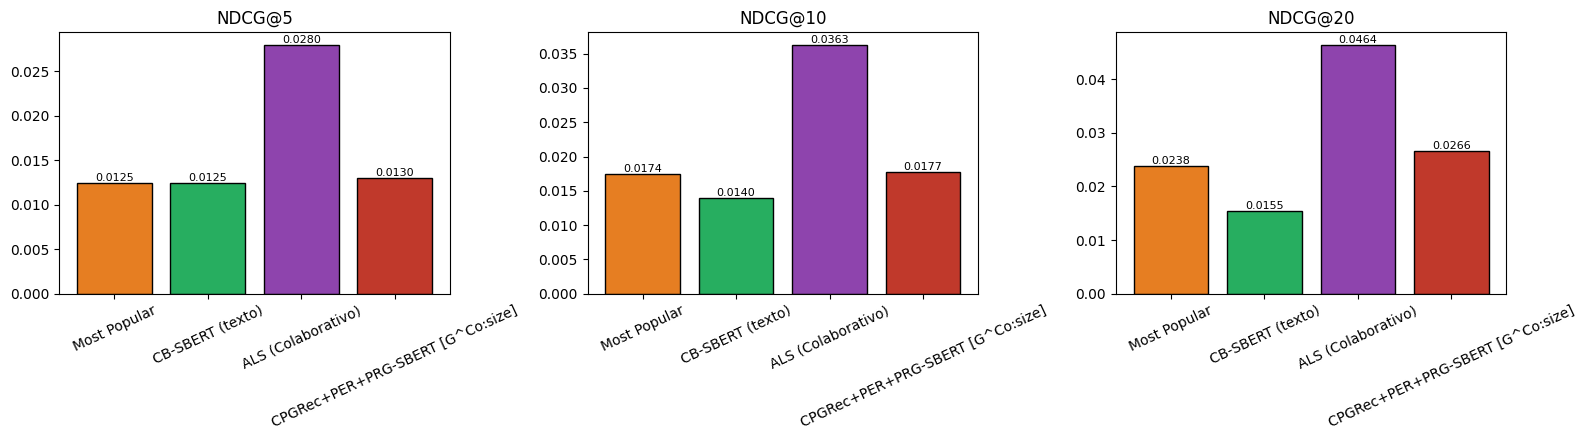

In [63]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, k in zip(axes, KS):
    v = results_df[f'NDCG@{k}']
    ax.bar(v.index, v.values, color=['#E67E22','#27AE60','#8E44AD','#C0392B'], edgecolor='black')
    ax.set_title(f'NDCG@{k}'); ax.tick_params(axis='x', rotation=25)
    for i, val in enumerate(v.values): ax.text(i, val, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.savefig('ndcg_h2_cpgrec.png', dpi=120, bbox_inches='tight'); plt.show()